In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score

# Set display options for better readability
pd.set_option('display.max_columns', None)
plt.style.use('default')

In [2]:
clusters = pd.read_csv('../data/final_clusters/spectral_13_clusters.csv')
other_reps = pd.read_csv('../data/final_clusters/cluster_other_representatives.csv')
clusters.rename(columns={'cluster': 'cluster_id'}, inplace=True)


In [3]:
print("=" * 60)
print("RECOMMENDATION SYSTEM CLUSTER PRECISION ANALYSIS")
print("=" * 60)

print("\n🧪 EXPERIMENTAL DESIGN")
print(f"Original dataset: {len(clusters)} anime clustered into {clusters['cluster_id'].nunique()} clusters")
print(f"Recommendations: {len(other_reps)} anime ({other_reps['cluster_id'].nunique()} clusters)")
print(f"Expected: ~{clusters['cluster_id'].nunique() * 10} recommendations (10 per cluster)")

print(f"\n📋 Testing: Do the {len(other_reps)} recommendations fall into their expected clusters?")


RECOMMENDATION SYSTEM CLUSTER PRECISION ANALYSIS

🧪 EXPERIMENTAL DESIGN
Original dataset: 2000 anime clustered into 13 clusters
Recommendations: 130 anime (13 clusters)
Expected: ~130 recommendations (10 per cluster)

📋 Testing: Do the 130 recommendations fall into their expected clusters?


In [4]:
print("\n🔍 RECOMMENDATION BREAKDOWN BY CLUSTER")

# Check how many recommendations per cluster were generated
recs_per_cluster = other_reps['cluster_id'].value_counts().sort_index()
print("Recommendations generated per cluster:")
for cluster_id, count in recs_per_cluster.items():
    print(f"  Cluster {cluster_id}: {count} recommendations")

# Check which recommended anime exist in the original dataset
recommended_anime = set(other_reps['anime_id'])
original_anime = set(clusters['anime_id'])
overlap_anime = recommended_anime & original_anime
external_anime = recommended_anime - original_anime

print(f"\n📊 Recommendation sources:")
print(f"  From original dataset: {len(overlap_anime)} anime")
print(f"  External discoveries: {len(external_anime)} anime")
print(f"  Total recommendations: {len(recommended_anime)} anime")


🔍 RECOMMENDATION BREAKDOWN BY CLUSTER
Recommendations generated per cluster:
  Cluster 1: 10 recommendations
  Cluster 2: 10 recommendations
  Cluster 3: 10 recommendations
  Cluster 4: 10 recommendations
  Cluster 5: 10 recommendations
  Cluster 6: 10 recommendations
  Cluster 7: 10 recommendations
  Cluster 8: 10 recommendations
  Cluster 9: 10 recommendations
  Cluster 10: 10 recommendations
  Cluster 11: 10 recommendations
  Cluster 12: 10 recommendations
  Cluster 13: 10 recommendations

📊 Recommendation sources:
  From original dataset: 117 anime
  External discoveries: 0 anime
  Total recommendations: 117 anime


In [5]:
print("\n🎯 CLUSTER PRECISION ANALYSIS")
print("For each recommendation cluster, where do the anime actually belong?")

# Merge only the overlapping anime to see cluster assignments
merged_overlap = pd.merge(clusters, other_reps, on='anime_id', how='inner',
                         suffixes=('_original', '_recommended'))

if len(merged_overlap) == 0:
    print("❌ No recommended anime found in original dataset!")
    print("All recommendations are external discoveries")
else:
    print(f"\nAnalyzing {len(merged_overlap)} recommendations that exist in original dataset:")
    
    # Calculate precision for each recommendation cluster
    precision_analysis = []
    
    for rec_cluster in sorted(merged_overlap['cluster_id_recommended'].unique()):
        cluster_recs = merged_overlap[merged_overlap['cluster_id_recommended'] == rec_cluster]
        
        # Where do these recommendations actually belong?
        actual_clusters = cluster_recs['cluster_id_original'].value_counts()
        
        # Calculate precision (% that match the intended cluster)
        correct_matches = actual_clusters.get(rec_cluster, 0)
        precision = correct_matches / len(cluster_recs)
        
        precision_analysis.append({
            'recommendation_cluster': rec_cluster,
            'total_recs': len(cluster_recs),
            'correct_cluster': correct_matches, 
            'precision': precision,
            'most_common_actual': actual_clusters.index[0],
            'most_common_count': actual_clusters.iloc[0]
        })
    
    # Create results DataFrame
    precision_df = pd.DataFrame(precision_analysis)
    
    # Display results
    print(f"\n{'Rec Cluster':<12} {'Total Recs':<10} {'Correct':<8} {'Precision':<10} {'Most Common Actual'}")
    print("-" * 65)
    
    for _, row in precision_df.iterrows():
        precision_pct = f"{row['precision']:.1%}"
        print(f"{row['recommendation_cluster']:<12} {row['total_recs']:<10} {row['correct_cluster']:<8} "
              f"{precision_pct:<10} Cluster {row['most_common_actual']} ({row['most_common_count']} anime)")



🎯 CLUSTER PRECISION ANALYSIS
For each recommendation cluster, where do the anime actually belong?

Analyzing 130 recommendations that exist in original dataset:

Rec Cluster  Total Recs Correct  Precision  Most Common Actual
-----------------------------------------------------------------
1.0          10.0       2.0      20.0%      Cluster 1.0 (2.0 anime)
2.0          10.0       5.0      50.0%      Cluster 2.0 (5.0 anime)
3.0          10.0       0.0      0.0%       Cluster 6.0 (5.0 anime)
4.0          10.0       1.0      10.0%      Cluster 2.0 (3.0 anime)
5.0          10.0       2.0      20.0%      Cluster 6.0 (4.0 anime)
6.0          10.0       4.0      40.0%      Cluster 6.0 (4.0 anime)
7.0          10.0       0.0      0.0%       Cluster 6.0 (4.0 anime)
8.0          10.0       2.0      20.0%      Cluster 6.0 (6.0 anime)
9.0          10.0       3.0      30.0%      Cluster 9.0 (3.0 anime)
10.0         10.0       1.0      10.0%      Cluster 6.0 (4.0 anime)
11.0         10.0       5.0 

In [6]:
print("\n🎲 PERFORMANCE vs RANDOM BASELINE")

# Define random baseline first
num_clusters = clusters['cluster_id'].nunique()
random_baseline = 1 / num_clusters

if len(merged_overlap) > 0:
    
    # Overall precision
    overall_correct = (merged_overlap['cluster_id_original'] == merged_overlap['cluster_id_recommended']).sum()
    overall_precision = overall_correct / len(merged_overlap)
    
    print(f"Random baseline precision: {random_baseline:.1%}")
    print(f"Actual precision: {overall_precision:.1%}")
    print(f"Improvement over random: {overall_precision/random_baseline:.1f}x")
    
    # Clustering similarity metrics
    labels_original = merged_overlap['cluster_id_original']
    labels_recommended = merged_overlap['cluster_id_recommended']
    
    ari = adjusted_rand_score(labels_original, labels_recommended)
    nmi = normalized_mutual_info_score(labels_original, labels_recommended)
    fmi = fowlkes_mallows_score(labels_original, labels_recommended)
    
    print(f"\n📈 Clustering Similarity Metrics:")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Info: {nmi:.3f}")
    print(f"Fowlkes-Mallows Index: {fmi:.3f}")
else:
    print("Cannot calculate metrics - no overlapping recommendations")


🎲 PERFORMANCE vs RANDOM BASELINE
Random baseline precision: 7.7%
Actual precision: 19.2%
Improvement over random: 2.5x

📈 Clustering Similarity Metrics:
Adjusted Rand Index: 0.043
Normalized Mutual Info: 0.302
Fowlkes-Mallows Index: 0.139


In [7]:
print("\n🌟 EXTERNAL DISCOVERIES ANALYSIS")

if len(external_anime) > 0:
    print(f"The recommendation system found {len(external_anime)} anime outside your original dataset!")
    
    # Show which clusters these external recommendations were assigned to
    external_recs = other_reps[other_reps['anime_id'].isin(external_anime)]
    external_by_cluster = external_recs['cluster_id'].value_counts().sort_index()
    
    print("\nExternal discoveries by recommendation cluster:")
    for cluster_id, count in external_by_cluster.items():
        print(f"  Cluster {cluster_id}: {count} external anime")
        
    print(f"\n💡 This suggests the recommendation system identified {len(external_anime)} anime")
    print("   similar to your cluster representatives but not in your original corpus")
else:
    print("All recommendations came from within your original 2000 anime dataset")



🌟 EXTERNAL DISCOVERIES ANALYSIS
All recommendations came from within your original 2000 anime dataset


In [8]:
print("\n🎯 SUMMARY & INTERPRETATION")
print("=" * 35)

if len(merged_overlap) > 0:
    # Calculate key metrics
    perfect_clusters = (precision_df['precision'] == 1.0).sum()
    good_clusters = (precision_df['precision'] > 0.5).sum()
    poor_clusters = len(precision_df) - good_clusters
    
    avg_precision = precision_df['precision'].mean()
    improvement = avg_precision / random_baseline if 'random_baseline' in locals() else 0
    
    print(f"📊 Overall recommendation precision: {overall_precision:.1%}")
    print(f"📊 Average cluster precision: {avg_precision:.1%}")
    print(f"🎲 Random baseline: {random_baseline:.1%}")
    print(f"⚡ Improvement over random: {improvement:.1f}x")
    
    print(f"\n🏆 Cluster Performance Breakdown:")
    print(f"  Perfect precision (100%): {perfect_clusters} clusters")
    print(f"  Good precision (>50%): {good_clusters} clusters")
    print(f"  Poor precision (<50%): {poor_clusters} clusters")
    
    # Interpretation
    if avg_precision > 0.7:
        performance = "🟢 EXCELLENT"
        verdict = "Recommendation system shows strong cluster structure awareness"
    elif avg_precision > 0.4:
        performance = "🟡 GOOD" 
        verdict = "Recommendation system shows moderate cluster structure awareness"
    elif avg_precision > random_baseline * 1.5:
        performance = "🟠 FAIR"
        verdict = "Recommendation system shows some cluster structure awareness"
    else:
        performance = "🔴 POOR"
        verdict = "Recommendation system shows little cluster structure awareness"
    
    print(f"\n🎭 Overall Assessment: {performance}")
    print(f"📋 {verdict}")
    
    if len(external_anime) > 0:
        external_pct = len(external_anime) / len(other_reps) * 100
        print(f"\n🌟 Bonus: Found {len(external_anime)} external anime ({external_pct:.1f}% of recommendations)")
        print("   This demonstrates the system's ability to find relevant content beyond your dataset")

# Display detailed results
if 'precision_df' in locals() and len(precision_df) > 0:
    print(f"\n📋 Detailed Precision Results:")
    display(precision_df)



🎯 SUMMARY & INTERPRETATION
📊 Overall recommendation precision: 19.2%
📊 Average cluster precision: 19.2%
🎲 Random baseline: 7.7%
⚡ Improvement over random: 2.5x

🏆 Cluster Performance Breakdown:
  Perfect precision (100%): 0 clusters
  Good precision (>50%): 0 clusters
  Poor precision (<50%): 13 clusters

🎭 Overall Assessment: 🟠 FAIR
📋 Recommendation system shows some cluster structure awareness

📋 Detailed Precision Results:


,recommendation_cluster,total_recs,correct_cluster,precision,most_common_actual,most_common_count
0,1,10,2,0.2,1,2
1,2,10,5,0.5,2,5
2,3,10,0,0.0,6,5
3,4,10,1,0.1,2,3
4,5,10,2,0.2,6,4
5,6,10,4,0.4,6,4
6,7,10,0,0.0,6,4
7,8,10,2,0.2,6,6
8,9,10,3,0.3,9,3
9,10,10,1,0.1,6,4


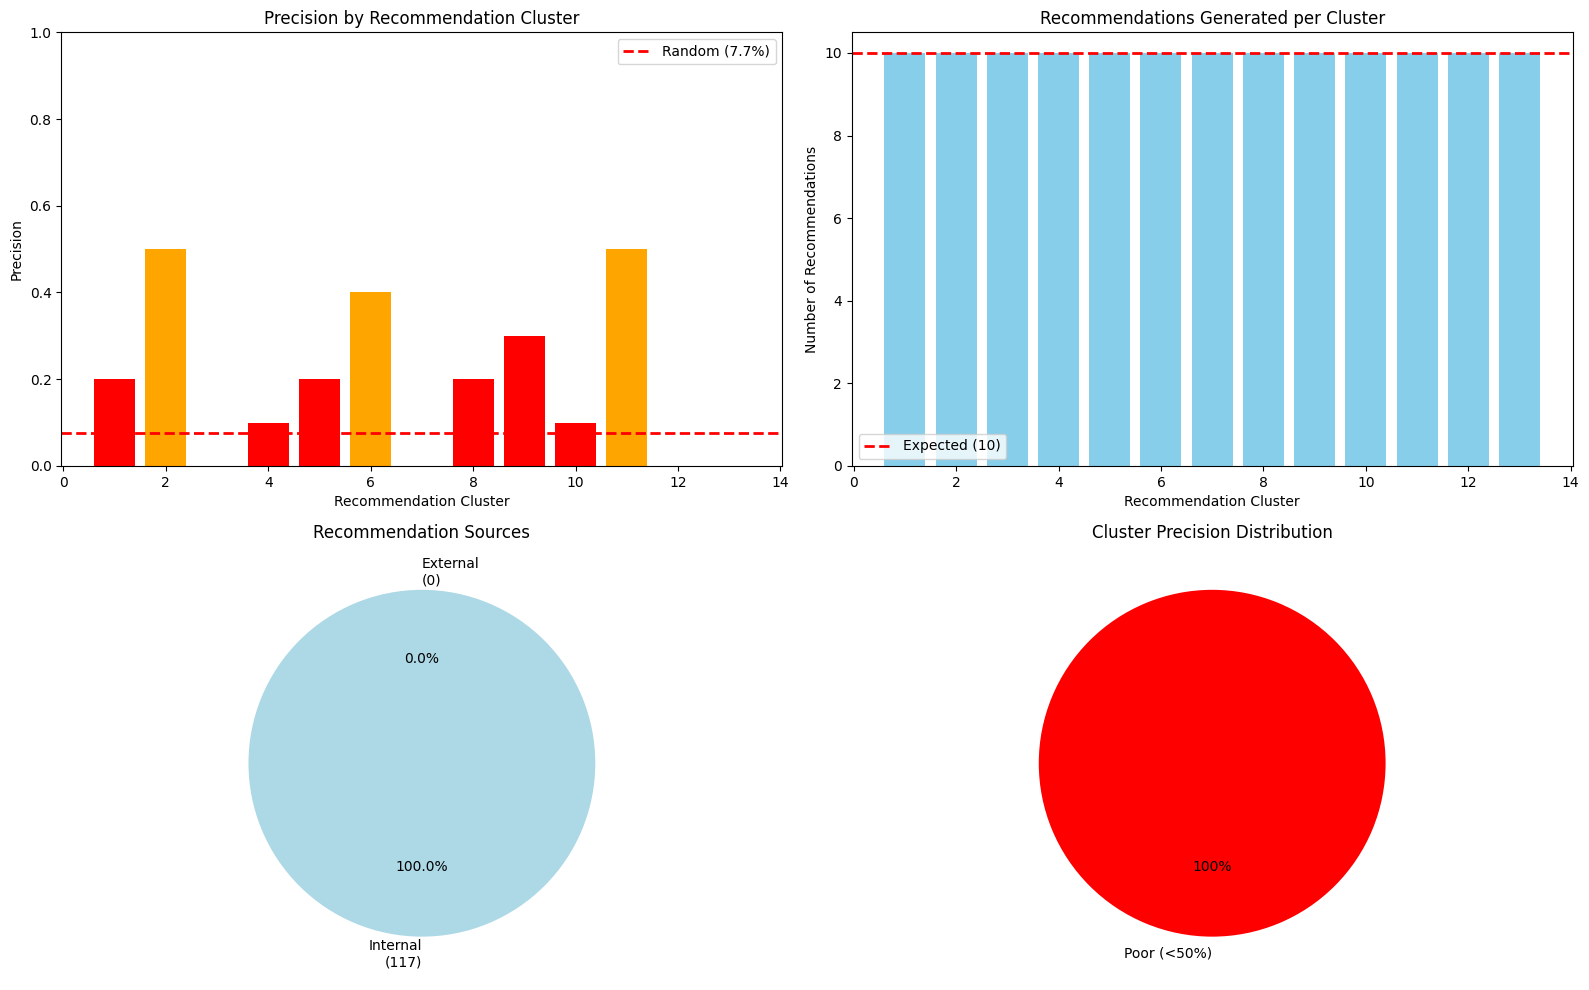


🔍 KEY INSIGHTS:
✅ Tested 130 recommendations against original cluster assignments
🎯 Achieved 19.2% precision (2.5x better than random)
🏆 0/13 clusters show good precision


In [9]:
# Create visualizations
if 'precision_df' in locals() and len(precision_df) > 0:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Precision by cluster
    colors = ['green' if x == 1.0 else 'lightgreen' if x > 0.5 else 'orange' if x > 0.3 else 'red' 
              for x in precision_df['precision']]
    bars1 = ax1.bar(precision_df['recommendation_cluster'], precision_df['precision'], color=colors)
    ax1.axhline(y=random_baseline, color='red', linestyle='--', label=f'Random ({random_baseline:.1%})', linewidth=2)
    ax1.set_xlabel('Recommendation Cluster')
    ax1.set_ylabel('Precision')
    ax1.set_title('Precision by Recommendation Cluster')
    ax1.legend()
    ax1.set_ylim(0, 1)
    
    # Plot 2: Recommendations per cluster
    ax2.bar(recs_per_cluster.index, recs_per_cluster.values, color='skyblue')
    ax2.axhline(y=10, color='red', linestyle='--', label='Expected (10)', linewidth=2)
    ax2.set_xlabel('Recommendation Cluster') 
    ax2.set_ylabel('Number of Recommendations')
    ax2.set_title('Recommendations Generated per Cluster')
    ax2.legend()
    
    # Plot 3: Internal vs External recommendations
    internal_count = len(overlap_anime)
    external_count = len(external_anime)
    ax3.pie([internal_count, external_count], 
            labels=[f'Internal\n({internal_count})', f'External\n({external_count})'],
            colors=['lightblue', 'lightcoral'],
            autopct='%1.1f%%',
            startangle=90)
    ax3.set_title('Recommendation Sources')
    
    # Plot 4: Performance summary
    perf_labels = ['Perfect (100%)', 'Good (>50%)', 'Poor (<50%)']
    perf_counts = [perfect_clusters, good_clusters - perfect_clusters, poor_clusters]
    perf_colors = ['green', 'yellow', 'red']
    
    # Filter out zero counts
    filtered_perf = [(l, c, col) for l, c, col in zip(perf_labels, perf_counts, perf_colors) if c > 0]
    if filtered_perf:
        labels_f, counts_f, colors_f = zip(*filtered_perf)
        ax4.pie(counts_f, labels=labels_f, colors=colors_f, autopct='%1.0f%%', startangle=90)
        ax4.set_title('Cluster Precision Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Final summary
    print(f"\n🔍 KEY INSIGHTS:")
    print(f"✅ Tested {len(merged_overlap)} recommendations against original cluster assignments")
    print(f"🎯 Achieved {overall_precision:.1%} precision ({improvement:.1f}x better than random)")
    if external_count > 0:
        print(f"🌟 Discovered {external_count} relevant anime outside original dataset")
    print(f"🏆 {perfect_clusters + good_clusters}/{len(precision_df)} clusters show good precision")
